In [ ]:
import pandas as pd
from utils import *
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt
import joblib

In [13]:
attrition_data = pd.read_excel(
    r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL data\Employee Master.xlsx',
    dtype={
        'EMP_CODE': str,
        'EMP_ID':str,
        'EMP_GENDER':str,
        'DEPARTMENT_NAME':str,
        'DESIGNATION': str,
        
    },
    parse_dates=['JOIN_DATE','LAST WORKING DATE'],
    date_format={
        'JOIN_DATE':"%d-%b-%Y",
        'LAST WORKING DATE': "%d-%b-%Y"
    }
)

In [28]:
((attrition_data['Employee Category'].str.lower() == 'permanent') & (attrition_data['LAST WORKING DATE'].notna())).sum()

46438

In [29]:
(attrition_data['Employee Category'].str.lower() == 'permanent').sum()

46839

In [6]:
attrition_data.columns

Index(['COMP_ID', 'EMP_ID', 'EMP_CODE', 'EMP_NAME', 'EMP_GENDER', 'JOIN_DATE',
       'COMPANY_NAME', 'BRANCH_NAME', 'DIVISION_NAME', 'DEPARTMENT_NAME',
       'DESIGNATION', 'GRADE_CODE', 'REPORTING_MANAGER', 'REPORTING_MD',
       'Employee Category', 'Resident Type', 'LAST WORKING DATE',
       'Tenure Ageing Bracket', 'Tenure Ageing Bracket Sort', 'New Grade',
       'Resignation date', 'RESIGNATION_REMARK', 'RESIGNATION_REASON',
       'BIRTH_DATE', 'MARITAL_STATUS', 'RELIGION'],
      dtype='object')

In [56]:
attrition_data["tenure"] = ((attrition_data['LAST WORKING DATE'] - attrition_data['JOIN_DATE']).dt.days / 30.44).round(2)

In [59]:
attrition_data.loc[attrition_data['tenure'].isna(), 'tenure'] = ((pd.Timestamp.now() - attrition_data.loc[attrition_data['tenure'].isna(),'JOIN_DATE']).dt.days / 30.44).round(2)

In [62]:
appraisal_data = pd.read_excel(
    r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL data\Appraisal - Predictive dashboard data.xlsx',
    skiprows=2,
    dtype={
        'EMPLOYEE_CODE': str,
        'FINAL_RATING': float,
    }
)

In [70]:
attrition_data['Performance'] = attrition_data['EMP_CODE'].map(appraisal_data.groupby('EMPLOYEE_CODE')['FINAL_RATING'].first())

In [71]:
attrition_data.describe()

,JOIN_DATE,LAST WORKING DATE,Tenure Ageing Bracket,Tenure Ageing Bracket Sort,New Grade,tenure,final_rating,Performance
count,128731,111265,111059.000000,0.0,0.0,128731.000000,128731.000000,128731.000000
mean,2019-04-07 04:36:17.825076992,2019-08-28 11:02:33.395946752,370.797090,NaN,NaN,14.149473,80.640234,80.640234
min,2001-10-15 00:00:00,2012-04-01 00:00:00,0.000000,NaN,NaN,0.000000,65.000000,65.000000
25%,2016-02-06 00:00:00,2016-08-31 00:00:00,49.000000,NaN,NaN,1.810000,78.000000,78.000000
50%,2019-07-04 00:00:00,2019-12-08 00:00:00,150.000000,NaN,NaN,5.850000,78.000000,78.000000
75%,2023-01-28 00:00:00,2023-02-08 00:00:00,452.000000,NaN,NaN,17.410000,78.000000,78.000000
max,2025-06-28 00:00:00,2025-07-09 00:00:00,6393.000000,NaN,NaN,252.460000,90.000000,90.000000
std,NaN,NaN,564.097179,NaN,NaN,21.379937,5.219829,5.219829


In [72]:
payroll_data = pd.read_excel(
    r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL data\Salary Data.xlsx',
    dtype={
        'EMPLOYEE CODE': str,
        'SALARY': float,
        'Monthly Bonus': float,
        'GRATUITY': float,
    }
)

In [73]:
payroll_data.columns

Index(['COMPANY CODE', 'COMPANY NAME', 'EMPLOYEE CODE', 'EMPLOYEE NAME',
       'LOCATION', 'DEPARTMENT', 'Date of joining', 'LEAVE DATE',
       'ACCOUNTING YEAR', 'SALARY', 'Monthly Bonus', 'GRATUITY',
       'EFFECTIVE DATE', 'END_MONTH', 'Tenure _join', 'Tenure _join sort'],
      dtype='object')

In [75]:
attrition_data['SALARY'] = attrition_data['EMP_CODE'].map(payroll_data.groupby('EMPLOYEE CODE')['SALARY'].last())
attrition_data['Monthly Bonus'] = attrition_data['EMP_CODE'].map(payroll_data.groupby('EMPLOYEE CODE')['Monthly Bonus'].last())
attrition_data['GRATUITY'] = attrition_data['EMP_CODE'].map(payroll_data.groupby('EMPLOYEE CODE')['GRATUITY'].last())

In [91]:
mean_salary = attrition_data[attrition_data['SALARY'].notna()].groupby('DESIGNATION')['SALARY'].mean()
mean_monthly_bonus = attrition_data[attrition_data['Monthly Bonus'].notna()].groupby('DESIGNATION')['Monthly Bonus'].mean()
mean_gratuity = attrition_data[attrition_data['GRATUITY'].notna()].groupby('DESIGNATION')['GRATUITY'].mean()
attrition_data.loc[(attrition_data['SALARY'].isna()), 'SALARY'] = attrition_data['DESIGNATION'].map(mean_salary)
attrition_data.loc[(attrition_data['Monthly Bonus'].isna()), 'Monthly Bonus'] = attrition_data['DESIGNATION'].map(mean_monthly_bonus)
attrition_data.loc[(attrition_data['GRATUITY'].isna()), 'GRATUITY'] = attrition_data['DESIGNATION'].map(mean_gratuity)

In [92]:
attrition_data.loc[(attrition_data['SALARY'].isna()), 'SALARY'] = attrition_data['SALARY'].mean()
attrition_data.loc[(attrition_data['GRATUITY'].isna()), 'GRATUITY'] = attrition_data['GRATUITY'].mean()
attrition_data.loc[(attrition_data['Monthly Bonus'].isna()), 'Monthly Bonus'] = attrition_data['Monthly Bonus'].mean()

In [79]:
overtime_data = pd.read_excel(
    r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL data\OT_DATA_PSIPL.xlsx',
    dtype={
        'EMP_MID': str,
        'SHIFT_NAME': str,
        
    },
    parse_dates=['Attendance Date'],
    date_format={
        'Attendance Date': '%m/%d/%Y'
    }
)

In [83]:
window_size = 15
overtime_data['rolling_avg'] = overtime_data.groupby('EMP_MID')['OT_HOURS'].transform(lambda x: x.rolling(window_size).mean())
overtime_data['rolling_avg'] = overtime_data['rolling_avg'].fillna(0.0)

In [86]:
attrition_data['overtime_rolling_average'] = attrition_data['EMP_CODE'].map(overtime_data.groupby('EMP_MID')['rolling_avg'].first())
attrition_data['overtime'] = attrition_data['EMP_CODE'].map(overtime_data.groupby('EMP_MID')['OT_HOURS'].first())
attrition_data['overtime_rolling_average'] = attrition_data['overtime_rolling_average'].fillna(0.0)
attrition_data['overtime'] = attrition_data['overtime'].fillna(0.0)

In [93]:
attrition_data['left'] = attrition_data['LAST WORKING DATE'].notna().astype(int)
current_employees = attrition_data[attrition_data['left'] == 0]
past_employees = attrition_data[attrition_data['left'] == 1]

In [95]:
len(current_employees)

17466

In [151]:
features = ['EMP_GENDER','tenure', 'Performance', 'SALARY', 'GRATUITY', 'Monthly Bonus','overtime_rolling_average','overtime']
X = attrition_data[features]
y = attrition_data['left']

In [152]:
categorical = ['EMP_GENDER']
numeric = ['tenure', 'Performance', 'SALARY', 'GRATUITY', 'Monthly Bonus', 'overtime_rolling_average','overtime']

preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first'))
    ]), categorical),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric)
])

In [153]:
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier())
])

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

In [155]:
len(X_test)

25747

In [156]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['EMP_GENDER']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure', 'Performance',
                                                   'SALARY', 'GRATUITY',
                                                   'Monthly Bonus',
                                                   'overtime_rolling_average',
                                                   'overtime'])])),
                ('model', RandomForestClassifier())])

In [157]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3493
           1       0.99      0.99      0.99     22254

    accuracy                           0.98     25747
   macro avg       0.98      0.95      0.96     25747
weighted avg       0.98      0.98      0.98     25747



In [158]:
X_curr = current_employees[features]

In [159]:
attrition_risk = pipeline.predict_proba(X_curr)[:, 1]
current_employees['Attrition_Risk_Percent'] = (attrition_risk * 100).round(2)

C:\Users\surya.iyer\AppData\Local\Temp\ipykernel_6592\700822085.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_employees['Attrition_Risk_Percent'] = (attrition_risk * 100).round(2)


In [160]:
attrition_risk.shape

(17466,)

In [162]:
# save current model to pickle file to be loaded later
from datetime import datetime
today = datetime.now().strftime("%d-%m-%Y")
joblib.dump(value=pipeline, filename=rf'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL models\attrition_risk_model_{today}.pkl')

['D:\\surya.iyer\\My Documents\\projects\\predictive analysis\\PSIPL models\\attrition_risk_model_16-06-2025.pkl']

### pickle testing

In [31]:
attrition_risk_model_pipeline = joblib.load(filename=r'D:\surya.iyer\My Documents\projects\predictive analysis\models\attrition_risk_model_14-05-2025.pkl')

In [140]:
attrition_risk_model_pipeline.predict_proba(X_test)

NameError: name 'attrition_risk_model_pipeline' is not defined

### rest of doc

In [161]:
current_employees['Attrition_Risk_Percent'].describe()

count    17466.000000
mean         8.290550
std         22.852191
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        100.000000
Name: Attrition_Risk_Percent, dtype: float64

In [163]:
current_employees.columns

Index(['COMP_ID', 'EMP_ID', 'EMP_CODE', 'EMP_NAME', 'EMP_GENDER', 'JOIN_DATE',
       'COMPANY_NAME', 'BRANCH_NAME', 'DIVISION_NAME', 'DEPARTMENT_NAME',
       'DESIGNATION', 'GRADE_CODE', 'REPORTING_MANAGER', 'REPORTING_MD',
       'Employee Category', 'Resident Type', 'LAST WORKING DATE',
       'Tenure Ageing Bracket', 'Tenure Ageing Bracket Sort', 'New Grade',
       'Resignation date', 'RESIGNATION_REMARK', 'RESIGNATION_REASON',
       'BIRTH_DATE', 'MARITAL_STATUS', 'RELIGION', 'tenure', 'final_rating',
       'Performance', 'SALARY', 'Monthly Bonus', 'GRATUITY',
       'overtime_rolling_average', 'overtime', 'left',
       'Attrition_Risk_Percent'],
      dtype='object')

In [165]:
current_employees.sort_values(by='Attrition_Risk_Percent', ascending=False).to_excel(r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL model predictions\attritrion_risk_prediction.xlsx', index=False)

In [168]:
current_employees['Attrition_Risk_Percent'].value_counts()

Attrition_Risk_Percent
0.00     10652
1.00      1882
2.00       934
3.00       510
4.00       362
         ...  
32.53        1
74.43        1
1.60         1
4.50         1
23.67        1
Name: count, Length: 562, dtype: int64

In [169]:
rf_model = pipeline.named_steps['model']
X_train_transformed = pipeline.named_steps['preprocess'].transform(X_train)

In [170]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_transformed)

: 

: 

In [40]:
shap_values.shape

(288, 17, 2)

In [41]:
X_train_transformed.shape

(288, 17)

<Figure size 640x480 with 0 Axes>

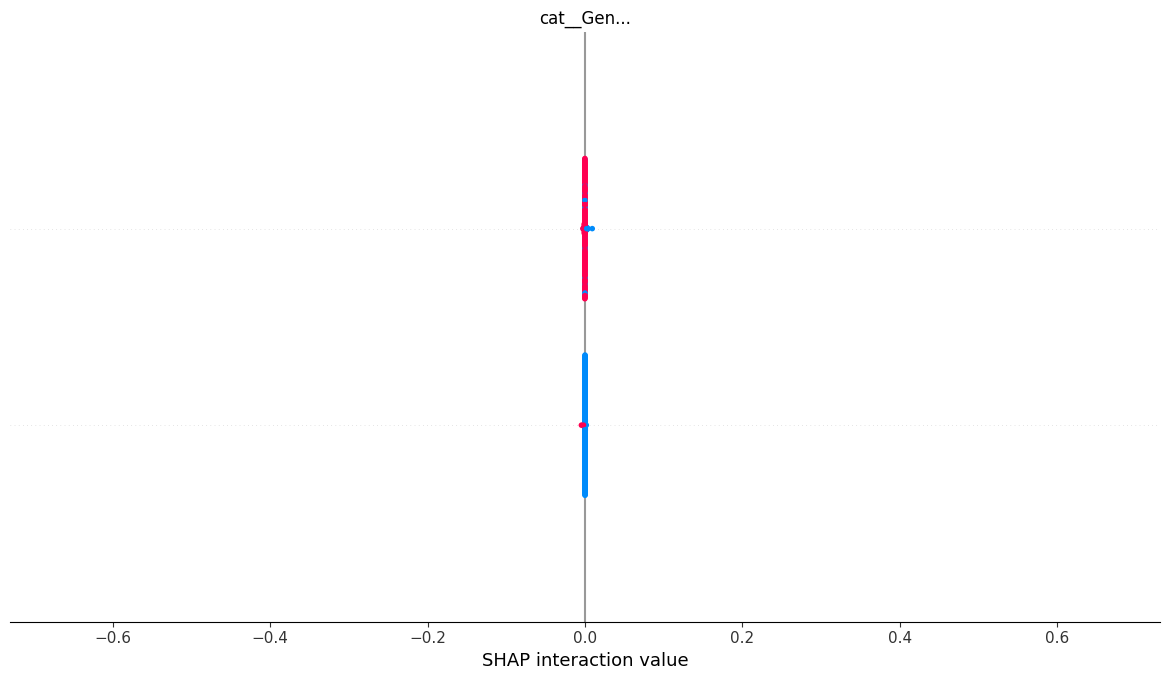

In [ ]:
try:
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
except:
    feature_names = [f"f{i}" for i in range(X_train_transformed.shape[1])]

# SHAP summary plot
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, plot_type="bar")